In [ ]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
import osmnx as ox


output_folder = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/"
file_names = [
    "Весь_Байкал_только_Хлорофилл_2002.csv",
    "Весь_Байкал_только_Хлорофилл_2003.csv",
    "Весь_Байкал_только_Хлорофилл_2004_2005.csv",
    "Весь_Байкал_только_Хлорофилл_2006_2007.csv",
    "Весь_Байкал_только_Хлорофилл_2008.csv",
    "Весь_Байкал_только_Хлорофилл_2009.csv",
    "Весь_Байкал_только_Хлорофилл_2010.csv",
    "Весь_Байкал_только_Хлорофилл_2011.csv",
    "Весь_Байкал_только_Хлорофилл_2012.csv",
    "Весь_Байкал_только_Хлорофилл_2016.csv",
    "Весь_Байкал_только_Хлорофилл_2017.csv",
    "Весь_Байкал_только_Хлорофилл_2018.csv",
    "Весь_Байкал_только_Хлорофилл_2019.csv",
    "Весь_Байкал_только_Хлорофилл_2020.csv",
]

# --- Загрузка данных ---
df_list = []
for file in file_names:
    path = os.path.join(output_folder, file)
    if os.path.exists(path):
        df_list.append(pd.read_csv(path))
    else:
        print(f"Файл не найден: {path}")
df = pd.concat(df_list, ignore_index=True)

In [ ]:
# --- Преобразование в геоданные ---
geometry = [Point(xy) for xy in zip(df["lon"], df["lat"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326").to_crs(epsg=32648)

# --- Загрузка полигона Байкала ---
lake = ox.features_from_place("Lake Baikal, Russia", tags={"natural": "water"})
lake = lake[lake.geometry.type.isin(["Polygon", "MultiPolygon"])].to_crs(epsg=32648)

# --- Создание сетки ---
L = 6000  # Размер ячейки

minx, miny, maxx, maxy = lake.total_bounds
grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        cell = box(x, y, x + L, y + L)
        grid_cells.append(cell)
        y += L
    x += L

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=lake.crs)
grid = grid[grid.intersects(lake.geometry.unary_union)].copy()
grid["cell_id"] = grid.index
grid["x_center"] = grid.geometry.centroid.x
grid["y_center"] = grid.geometry.centroid.y

c:\Users\fusb1\AppData\Local\Programs\Python\Python313\Lib\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 27 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)
C:\Users\fusb1\AppData\Local\Temp\ipykernel_6980\1219326541.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid = grid[grid.intersects(lake.geometry.unary_union)].copy()


In [ ]:
# --- Сохранение координат ячеек (таблица а - id и координата ячеек)  ---
cell_coords_df = grid[["cell_id", "x_center", "y_center"]]
output_a = os.path.join(output_folder, f"{L}_ячейки.csv")
cell_coords_df.to_csv(output_a, index=False, encoding='utf-8-sig')
print('таблица а пройдена')

# --- Привязка значений хлорофилла и точности к ячейкам (таблица б - дата, координаты, хлорофилл, точность, id) ---
joined = gpd.sjoin(gdf, grid[["cell_id", "x_center", "y_center", "geometry"]], predicate="within", how="inner")
joined["lon"] = joined["x_center"]
joined["lat"] = joined["y_center"]
final_df = joined[["date", "lat", "lon", "chla_mean", "chla_uncertainty", "cell_id"]]

output_b = os.path.join(output_folder, f"значения_хлорофилла_{L}_все_точки.csv")
final_df.to_csv(output_b, index=False, encoding='utf-8-sig')
print('таблица б пройдена') 

таблица а пройдена
таблица б пройдена


In [ ]:
#  --- в обучающую матрицу  HGBM вошли 3 таблицы "ОЧИЩЕНО_6000_матрица_из_ячеек_все_годы.csv", 
#  --- для этого 3 таблицы "6000_матрица_из_ячеек_все_годы.csv", были обработаны: бsли удалены пустые ячейки, пустые дни, отрегулирована точность

import pandas as pd
import os

# пути к файлам
path_a = r"C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/6000_ячейки.csv"
path_b = r"C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/значения_хлорофилла_6000_все_точки.csv"
output_path = r"C:/Users/fusb1/Desktop/Для git/6000_матрица_из_ячеек_все_годы.csv"

# --- Загрузка таблицы б ---
df_b = pd.read_csv(path_b)

# --- Фильтрация по точности ---
df_filtered = df_b[df_b["chla_uncertainty"] >= 50].copy()

# --- Создаём широкую таблицу: строки = даты, столбцы = cell_id ---
table_v = df_filtered.pivot_table(
    index="date",
    columns="cell_id",
    values="chla_mean",
    aggfunc="mean"
)

# --- Сброс индекса для обычной структуры ---
table_v.reset_index(inplace=True)

# --- Сохранение ---
os.makedirs(os.path.dirname(output_path), exist_ok=True)
table_v.to_csv(output_path, index=False, encoding='utf-8-sig')

print("Таблица '6000_матрица_из_ячеек_все_годы.csv' успешно создана и сохранена!")



Таблица '6000_матрица_из_ячеек_все_годы.csv' успешно создана и сохранена!


In [7]:
# --- Подготовка шаблона всех дат и ячеек ---
all_dates = final_df["date"].unique()
all_cells = final_df["cell_id"].unique()
date_cell_template = pd.MultiIndex.from_product([all_dates, all_cells], names=["date", "cell_id"]).to_frame(index=False)

# --- Обработка по порогам точности ---
total_values_list = []
non_zero_list = []
zero_list = []
un_recorded = []


Обработка для точности ≥ 37
Файл сохранён: C:/Users/fusb1/Desktop/После Рыбки\6000_хлорофилл_от_37_точность.csv
Всего значений: 2960048
Ненулевых: 776904 (26.25%)
Нулевых: 2183144 (73.75%)

Обработка для точности ≥ 40
Файл сохранён: C:/Users/fusb1/Desktop/После Рыбки\6000_хлорофилл_от_40_точность.csv
Всего значений: 2960048
Ненулевых: 774069 (26.15%)
Нулевых: 2185979 (73.85%)

Обработка для точности ≥ 43
Файл сохранён: C:/Users/fusb1/Desktop/После Рыбки\6000_хлорофилл_от_43_точность.csv
Всего значений: 2960048
Ненулевых: 767595 (25.93%)
Нулевых: 2192453 (74.07%)

Обработка для точности ≥ 46
Файл сохранён: C:/Users/fusb1/Desktop/После Рыбки\6000_хлорофилл_от_46_точность.csv
Всего значений: 2960048
Ненулевых: 763265 (25.79%)
Нулевых: 2196783 (74.21%)

Обработка для точности ≥ 49
Файл сохранён: C:/Users/fusb1/Desktop/После Рыбки\6000_хлорофилл_от_49_точность.csv
Всего значений: 2960048
Ненулевых: 758593 (25.63%)
Нулевых: 2201455 (74.37%)

Обработка для точности ≥ 52
Файл сохранён: C:/Use

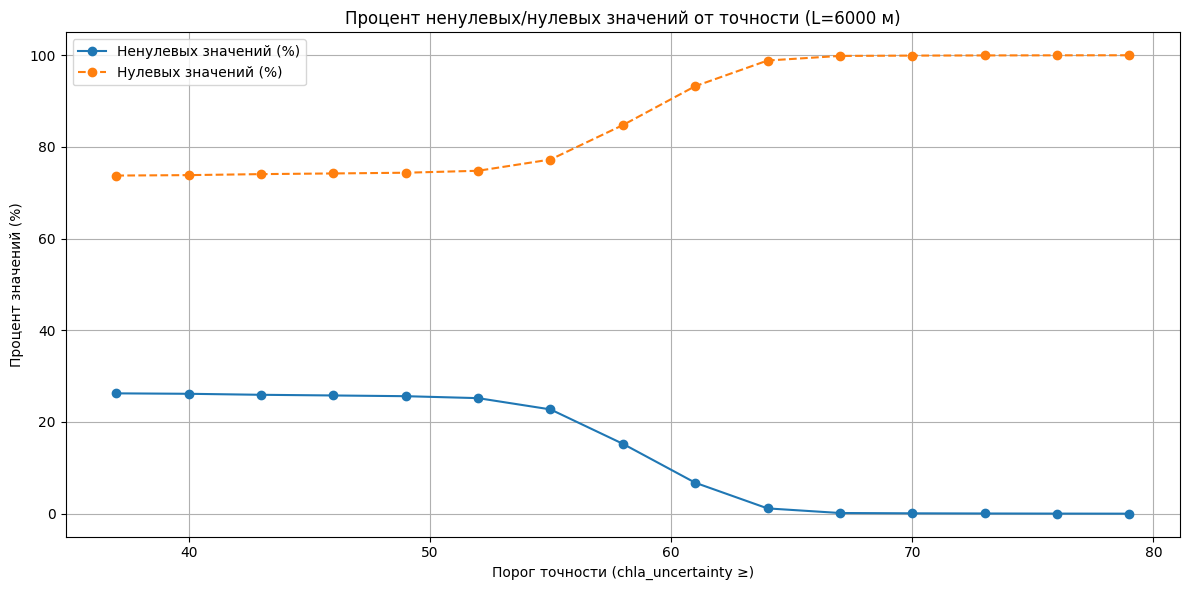

In [8]:
uncertainty_thresholds = list(range(37, 82, 3))  # От 40 до 70 включительно

for un in uncertainty_thresholds:
    print(f"\nОбработка для точности ≥ {un}")
    filtered = final_df[final_df["chla_uncertainty"] >= un]

    if filtered.empty:
        print("Нет данных для данной точности.")
        continue

    # Среднее значение по ячейке и дате
    grouped = filtered.groupby(["date", "cell_id"])["chla_mean"].mean().reset_index()

    # Объединение с полным шаблоном
    full_table = pd.merge(date_cell_template, grouped, on=["date", "cell_id"], how="left").fillna(0.0)

    pivot_df = full_table.pivot(index="date", columns="cell_id", values="chla_mean").reset_index()
    pivot_df.columns.name = None

    output_final = os.path.join("C:/Users/fusb1/Desktop/После Рыбки", f"{L}_хлорофилл_от_{un}_точность.csv")
    pivot_df.to_csv(output_final, index=False, encoding='utf-8-sig')

    total_values = pivot_df.iloc[:, 1:].size
    non_zero = (pivot_df.iloc[:, 1:] != 0).sum().sum()
    zero = total_values - non_zero

    print(f"Файл сохранён: {output_final}")
    print(f"Всего значений: {total_values}")
    print(f"Ненулевых: {non_zero} ({non_zero / total_values:.2%})")
    print(f"Нулевых: {zero} ({zero / total_values:.2%})")

    un_recorded.append(un)
    total_values_list.append(total_values)
    non_zero_list.append(non_zero)
    zero_list.append(zero)

# --- График в процентах ---
percent_non_zero = [nz / total * 100 for nz, total in zip(non_zero_list, total_values_list)]
percent_zero = [100 - p for p in percent_non_zero]

plt.figure(figsize=(12, 6))
plt.plot(un_recorded, percent_non_zero, marker='o', label='Ненулевых значений (%)')
plt.plot(un_recorded, percent_zero, marker='o', label='Нулевых значений (%)', linestyle='--')
plt.title(f'Процент ненулевых/нулевых значений от точности (L={L} м)')
plt.xlabel('Порог точности (chla_uncertainty ≥)')
plt.ylabel('Процент значений (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import haversine as hs
from sklearn.metrics import mean_squared_error

# Радиус фильтрации (в км)
R = 6

# Координаты точки (широта, долгота)
ref_point = (51.880377200040236, 105.08478832167806)

# Загрузка данных
df = pd.read_csv('C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_6km.csv') #
df_real = pd.read_csv('C:/Users/fusb1/Desktop/После Рыбки/Y_глубины/Y1_(глубина_=_0).csv')

# Оставляем только нужные столбцы
df = df[['date', 'chla_mean', 'chla_uncertainty']]

# Преобразуем столбец 'date' в datetime
df['date'] = pd.to_datetime(df['date']).dt.date
df_real['date'] = pd.to_datetime(df_real['date']).dt.date

# Преобразуем столбцы с хлорофиллом в формат float
df['chla_mean'] = df['chla_mean'].astype(float)  # Убедимся, что это float
df_real['хлорофилл'] = df_real['хлорофилл'].replace(r'[^0-9.,]', '', regex=True)
df_real['хлорофилл'] = df_real['хлорофилл'].str.replace(',', '.').astype(float)  # Преобразуем в float

dfs = {}

for i in range(37, 82, 3):  
    df_filtered = df[df['chla_uncertainty'] > i]
    
    # Сохраняем таблицу в словарь с ключом df{i}
    dfs[f'df{i+1}'] = df_filtered

# Теперь для каждой из таблиц вычислим среднее значение chla_mean по дням
dfs_avg = {}

for key, data in dfs.items():
    # Группируем по дате и вычисляем среднее значение chla_mean
    dfs_avg[key] = data.groupby('date')['chla_mean'].mean().reset_index()

# Выводим примеры первых строк каждой таблицы для проверки
for key, avg_df in dfs_avg.items():
    print(f"Таблица {key} (среднее значение по дням):")
    print(avg_df.head(), "\n") 

Таблица df38 (среднее значение по дням):
         date  chla_mean
0  2002-05-23   1.263318
1  2002-06-21   0.176241
2  2002-06-24   0.149847
3  2002-07-03   0.372770
4  2002-07-10   0.414834 

Таблица df41 (среднее значение по дням):
         date  chla_mean
0  2002-05-23   1.263318
1  2002-06-21   0.176241
2  2002-06-24   0.149847
3  2002-07-03   0.372770
4  2002-07-10   0.414834 

Таблица df44 (среднее значение по дням):
         date  chla_mean
0  2002-05-23   1.263318
1  2002-06-21   0.176241
2  2002-06-24   0.149847
3  2002-07-03   0.372770
4  2002-07-10   0.414834 

Таблица df47 (среднее значение по дням):
         date  chla_mean
0  2002-05-23   1.263318
1  2002-06-21   0.176241
2  2002-06-24   0.149847
3  2002-07-03   0.372770
4  2002-07-10   0.414834 

Таблица df50 (среднее значение по дням):
         date  chla_mean
0  2002-05-23   1.263318
1  2002-06-21   0.176241
2  2002-06-24   0.149847
3  2002-07-03   0.372770
4  2002-07-10   0.414834 

Таблица df53 (среднее значение по д

In [29]:
# Создаем словарь для таблиц с фильтрацией
dfs = {}

for i in range(37, 82, 3):  
    df_filtered = df[df['chla_uncertainty'] > i]
    
    # Сохраняем таблицу в словарь с ключом df{i+1}
    dfs[f'df{i+3}'] = df_filtered

# Проверим, что таблицы созданы
dfs.keys()

dict_keys(['df40', 'df43', 'df46', 'df49', 'df52', 'df55', 'df58', 'df61', 'df64', 'df67', 'df70', 'df73', 'df76', 'df79', 'df82'])

In [30]:
# Теперь для каждой из таблиц вычислим среднее значение chla_mean по дням
dfs_avg = {}

for key, data in dfs.items():
    # Группируем по дате и вычисляем среднее значение chla_mean
    dfs_avg[key] = data.groupby('date')['chla_mean'].mean().reset_index()

# Проверим, как выглядят результаты для одной из таблиц
dfs_avg['df40'].head()

,date,chla_mean
0,2002-05-23,1.263318
1,2002-06-21,0.176241
2,2002-06-24,0.149847
3,2002-07-03,0.372770
4,2002-07-10,0.414834


In [31]:
from sklearn.metrics import mean_squared_error
mse_results = {}

for key in dfs:  
    
    df_current = dfs[key]
    merged_df = pd.merge(df_current, df_real, on='date', how='inner')

    # Фильтруем строки, где значения в столбцах 'chla_mean' или 'Хлорофилл' равны 0 или отсутствуют (NaN)
    merged_df = merged_df[(merged_df['chla_mean'] != 0) & 
                          (merged_df['хлорофилл'] != 0) & 
                          merged_df['chla_mean'].notna() & 
                          merged_df['хлорофилл'].notna()]

    # Рассчитываем среднюю ошибку (MSE) между значениями хлорофилла
    if not merged_df.empty:
        mse_value = mean_squared_error(merged_df['хлорофилл'], merged_df['chla_mean'])
        mse_results[key] = mse_value
        if mse_value < 12:
            print(f'Средняя ошибка (MSE) для {key}: {mse_value}')
    else:
        print(f"После фильтрации данных для таблицы {key}, пуста. Проверьте данные.")

Средняя ошибка (MSE) для df40: 7.091752439134351
Средняя ошибка (MSE) для df43: 7.091752439134351
Средняя ошибка (MSE) для df46: 6.734680942448519
Средняя ошибка (MSE) для df49: 6.488966539167584
Средняя ошибка (MSE) для df52: 6.488966539167584
Средняя ошибка (MSE) для df55: 6.219296721350848
Средняя ошибка (MSE) для df58: 4.449598462103664
Средняя ошибка (MSE) для df61: 1.2429968242664928
Средняя ошибка (MSE) для df64: 1.7623228648276938
Средняя ошибка (MSE) для df67: 0.9181426409954923
После фильтрации данных для таблицы df76, пуста. Проверьте данные.
После фильтрации данных для таблицы df79, пуста. Проверьте данные.
После фильтрации данных для таблицы df82, пуста. Проверьте данные.


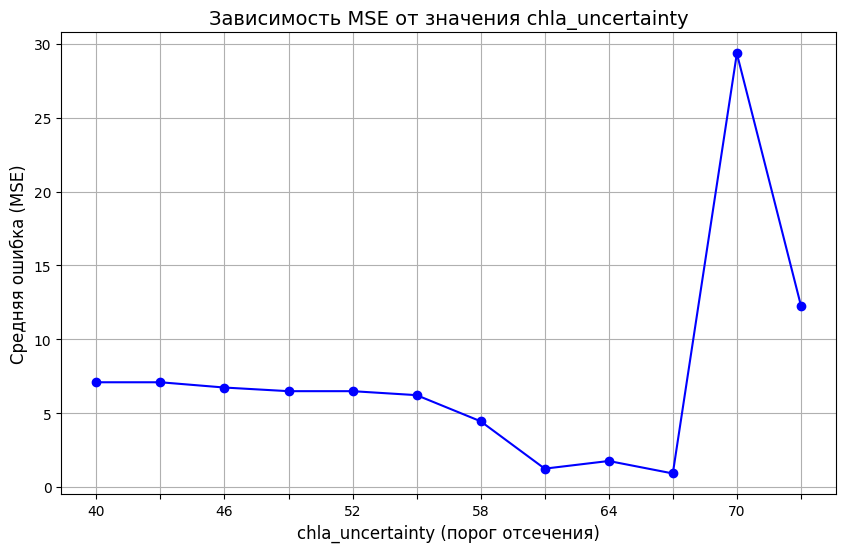

In [32]:
import matplotlib.pyplot as plt

# Преобразуем ключи в числа (например, 'df21' → 21)
uncertainty_values = sorted([int(key.replace('df', '')) for key in mse_results.keys()])
mse_values = [mse_results[f'df{val}'] for val in uncertainty_values]

plt.figure(figsize=(10, 6))
plt.plot(uncertainty_values, mse_values, marker='o', linestyle='-', color='blue')
plt.title('Зависимость MSE от значения chla_uncertainty', fontsize=14)
plt.xlabel('chla_uncertainty (порог отсечения)', fontsize=12)
plt.ylabel('Средняя ошибка (MSE)', fontsize=12)
plt.grid(True)

# Показываем подписи только на каждой 4-й метке
xtick_labels = [val if i % 2 == 0 else '' for i, val in enumerate(uncertainty_values)]
plt.xticks(uncertainty_values, labels=xtick_labels)

plt.show()

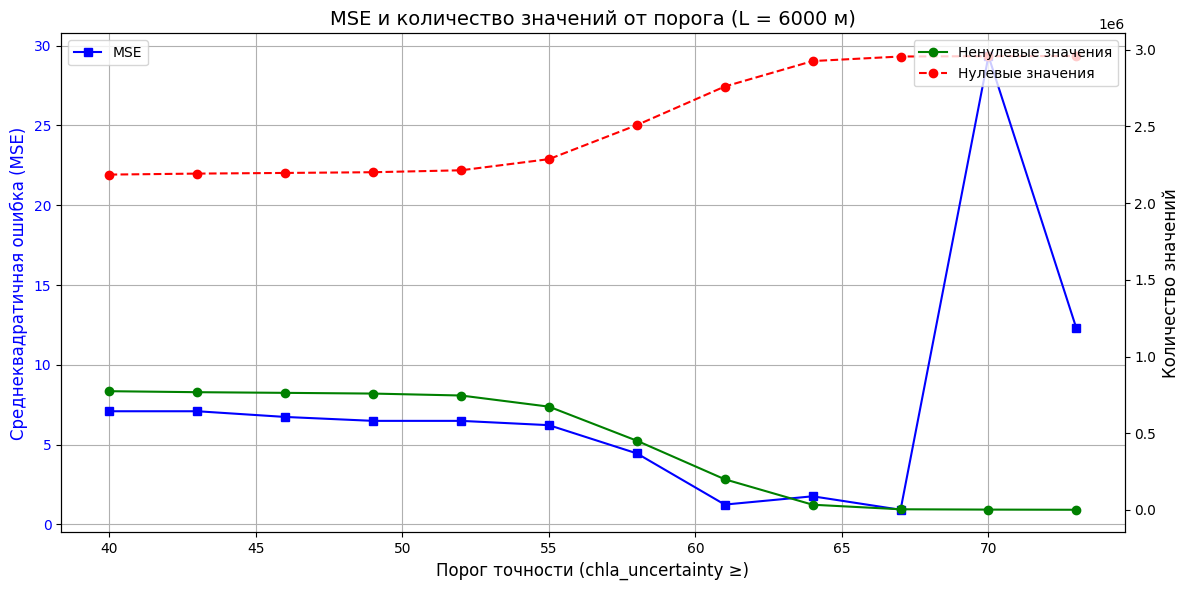

In [33]:
import matplotlib.pyplot as plt

# --- Подготовка ---
mse_uncertainty = sorted([int(key.replace('df', '')) for key in mse_results.keys()])
nz_dict = dict(zip(un_recorded, non_zero_list))
total_dict = dict(zip(un_recorded, total_values_list))

valid_uncertainties = [u for u in mse_uncertainty if u in nz_dict]

non_zero_counts = [nz_dict[u] for u in valid_uncertainties]
zero_counts = [total_dict[u] - nz_dict[u] for u in valid_uncertainties]
mse_values = [mse_results[f'df{u}'] for u in valid_uncertainties]

# --- Построение ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Левая ось: MSE
ax1.plot(valid_uncertainties, mse_values, marker='s', linestyle='-', color='blue', label='MSE')
ax1.set_xlabel('Порог точности (chla_uncertainty ≥)', fontsize=12)
ax1.set_ylabel('Среднеквадратичная ошибка (MSE)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')
ax1.grid(True)

# Правая ось: количества
ax2 = ax1.twinx()
ax2.plot(valid_uncertainties, non_zero_counts, marker='o', color='green', label='Ненулевые значения')
ax2.plot(valid_uncertainties, zero_counts, marker='o', color='red', linestyle='--', label='Нулевые значения')
ax2.set_ylabel('Количество значений', color='black', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='upper right')

plt.title(f'MSE и количество значений от порога (L = {L} м)', fontsize=14)
plt.tight_layout()
plt.show()

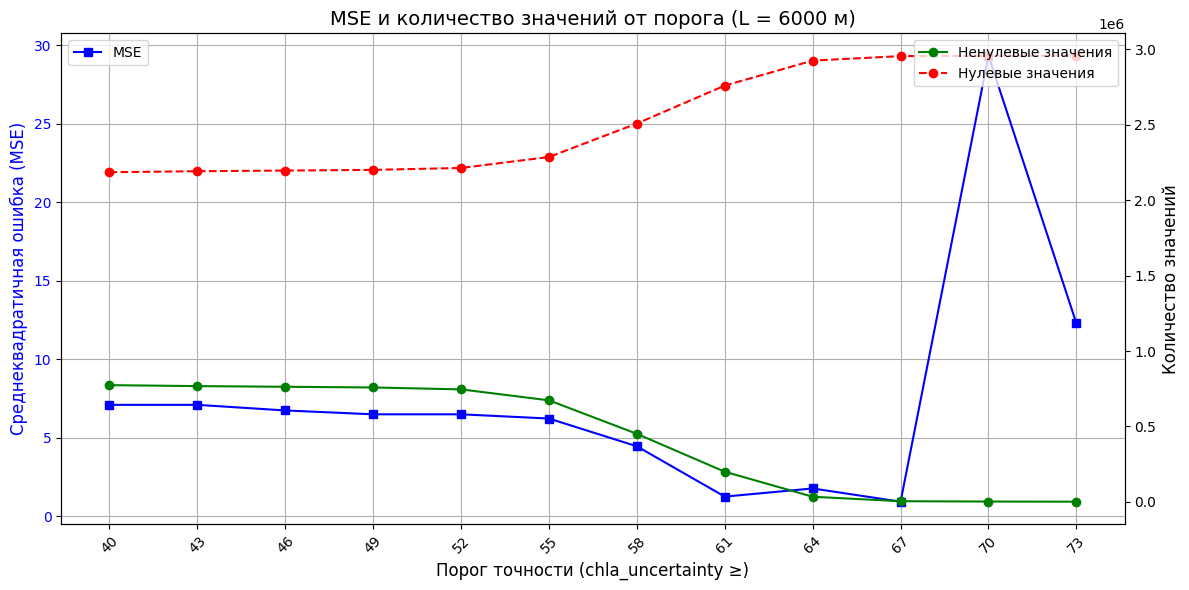

In [34]:
import matplotlib.pyplot as plt

# --- Подготовка ---
mse_uncertainty = sorted([int(key.replace('df', '')) for key in mse_results.keys()])
nz_dict = dict(zip(un_recorded, non_zero_list))
total_dict = dict(zip(un_recorded, total_values_list))

valid_uncertainties = [u for u in mse_uncertainty if u in nz_dict]

non_zero_counts = [nz_dict[u] for u in valid_uncertainties]
zero_counts = [total_dict[u] - nz_dict[u] for u in valid_uncertainties]
mse_values = [mse_results[f'df{u}'] for u in valid_uncertainties]

# --- Построение ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Левая ось: MSE
ax1.plot(valid_uncertainties, mse_values, marker='s', linestyle='-', color='blue', label='MSE')
ax1.set_xlabel('Порог точности (chla_uncertainty ≥)', fontsize=12)
ax1.set_ylabel('Среднеквадратичная ошибка (MSE)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')
ax1.grid(True)

# Правая ось: количества
ax2 = ax1.twinx()
ax2.plot(valid_uncertainties, non_zero_counts, marker='o', color='green', label='Ненулевые значения')
ax2.plot(valid_uncertainties, zero_counts, marker='o', color='red', linestyle='--', label='Нулевые значения')
ax2.set_ylabel('Количество значений', color='black', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='upper right')

# Подписи по оси X с шагом 1
ax1.set_xticks(valid_uncertainties)
ax1.set_xticklabels(valid_uncertainties, rotation=45, fontsize=10)

plt.title(f'MSE и количество значений от порога (L = {L} м)', fontsize=14)
plt.tight_layout()
plt.show()


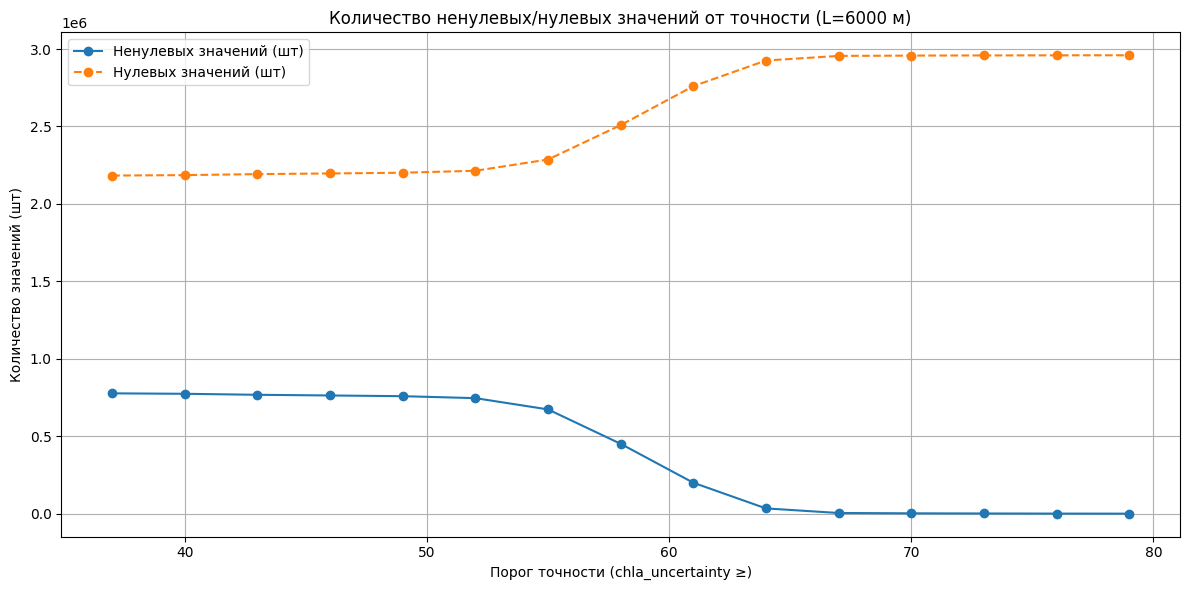

In [35]:
# --- График абсолютных значений ---
plt.figure(figsize=(12, 6))
plt.plot(un_recorded, non_zero_list, marker='o', label='Ненулевых значений (шт)')
plt.plot(un_recorded, zero_list, marker='o', label='Нулевых значений (шт)', linestyle='--')
plt.title(f'Количество ненулевых/нулевых значений от точности (L={L} м)')
plt.xlabel('Порог точности (chla_uncertainty ≥)')
plt.ylabel('Количество значений (шт)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()